# P-CULTA —  SFT 51 Evaluation
## Utterance+Context+Roles Condition

This notebook evaluates only the **SFT 51 Utterance+Context+Roles** condition.

Models:
- Qwen2.5-7B-Instruct
- Meta-Llama-3.1-8B-Instruct
- Qalb-1.0-8B-Instruct

Workflow:
1. Merge the three SFT response CSVs.
2. Create blinded Judge 1 / Judge 2 CSV annotation files.
3. Create a separate CSV mapping key.
4. After annotation, compute CAS, FTV, Bias, Cohen's kappa, summary statistics, significance tests, figures, and bias evidence.



## 0. Imports

In [1]:
# !pip install openai transformers accelerate bitsandbytes pandas scipy scikit-learn matplotlib seaborn tqdm -q
# !pip install -q openai
import os, time, warnings, json
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from tqdm.notebook import tqdm
from scipy import stats
from sklearn.metrics import cohen_kappa_score
from collections import Counter

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--'
})

COLORS = {
    'Qwen2.5-7B-Instruct':        '#1B7837',
    'Meta-Llama-3.1-8B-Instruct': '#D6604D',
    'Qalb-1.0-8B-Instruct':       '#7B2D8B',
}

print("✓ Ready")

✓ Ready


## 1. File Paths

In [2]:
BASE_DATA_PATH = r"P_CULTA_V2.csv"

SFT_FILES = {
    "Qwen2.5-7B-Instruct":        r"51_SFT_U_C_R_qwen_test.csv",
    "Meta-Llama-3.1-8B-Instruct": r"51_SFT_U_C_R_llama_test.csv",
    "Qalb-1.0-8B-Instruct":       r"51_SFT_U_C_R_Qalb_test.csv",
}

EXPECTED_N = 255

print("Utterance+Context+Roles SFT files:")
for model, path in SFT_FILES.items():
    print(f"  {model:38s} -> {path}")

Utterance+Context+Roles SFT files:
  Qwen2.5-7B-Instruct                    -> 51_SFT_U_C_R_qwen_test.csv
  Meta-Llama-3.1-8B-Instruct             -> 51_SFT_U_C_R_llama_test.csv
  Qalb-1.0-8B-Instruct                   -> 51_SFT_U_C_R_Qalb_test.csv


## 2. Load Base Dataset

In [3]:
base_df = pd.read_csv(BASE_DATA_PATH)

for col in [
    'Topic', 'Power Distance', 'Register',
    'Sensitivity', 'User Role', 'Model Role'
]:
    if col in base_df.columns:
        base_df[col] = base_df[col].astype(str).str.strip()

if 'Sensitivity' in base_df.columns:
    base_df['Sensitivity'] = base_df['Sensitivity'].str.capitalize()

base_df = base_df.reset_index(drop=True)

if 'ID' in base_df.columns:
    base_df = base_df.drop(columns=['ID'])

base_df.insert(0, 'ID', range(1, len(base_df) + 1))

assert len(base_df) == EXPECTED_N, (
    f"Expected {EXPECTED_N} rows, found {len(base_df)}"
)

print(f"Rows: {len(base_df)}")
print(base_df.columns.tolist())
base_df.head(3)

Rows: 255
['ID', 'Language', 'Topic', 'User Role', 'Model Role', 'Power Distance', 'Register', 'Pragmatic Genre', 'Sensitivity', 'User Utterance', 'Context', 'Gold Response']


,ID,Language,Topic,User Role,Model Role,Power Distance,Register,Pragmatic Genre,Sensitivity,User Utterance,Context,Gold Response
0,1,Urdu,Refusing Offers,میزبان,مہمان,Medium,Formal,Gratitude + indirect refusal,Positive,اور سالن لے لیجیے، ابھی گرم ہے۔,آپ ایک دعوت میں مہمان ہیں۔ کھانے کے دوران میزب...,آپ کی بڑی مہربانی، واقعی بہت مزیدار تھا، مگر ا...
1,2,Urdu,Refusing Offers,دوست,دوست,Low,Informal,Polite refusal,Negative,اور چائے بنوا دوں؟,آپ اپنے دوست کے گھر ملاقات کے لیے گئے ہیں۔ گفت...,نہیں یار، تم نے پہلے ہی بہت خاطر داری کر لی ہے...
2,3,Urdu,Refusing Offers,ساس,بہو,High,Formal,Deferential refusal,Positive,بیٹا، اور روٹی لے لو۔,آپ گھر میں کھانے کی میز پر موجود ہیں۔ کھانے کے...,جی امی جان، بہت شکریہ، مگر واقعی اب مزید گنجائ...


## 3. Merge Three Utterance+Context SFT Response Files

In [4]:
MODEL_OUTPUT_COLS = {
    'Qwen2.5-7B-Instruct':        'Qwen_Response',
    'Meta-Llama-3.1-8B-Instruct': 'LLaMA_Response',
    'Qalb-1.0-8B-Instruct':       'Qalb_Response',
}

RESPONSE_CANDIDATES = {
    'Qwen2.5-7B-Instruct': [
        'Qwen_Response', 'Generated Response',
        'Generated_Response', 'Response'
    ],
    'Meta-Llama-3.1-8B-Instruct': [
        'LLaMA_Response', 'Llama_Response',
        'Generated Response', 'Generated_Response', 'Response'
    ],
    'Qalb-1.0-8B-Instruct': [
        'Qalb_Response', 'Generated Response',
        'Generated_Response', 'Response'
    ],
}

def find_response_column(df, model):
    for col in RESPONSE_CANDIDATES[model]:
        if col in df.columns:
            return col

    possible = [
        c for c in df.columns
        if 'response' in c.lower()
        and c.lower() not in {'gold response', 'gold_response'}
    ]

    if len(possible) == 1:
        return possible[0]

    raise ValueError(
        f"Cannot identify response column for {model}. "
        f"Columns: {df.columns.tolist()}"
    )

def prepare_response_file(path, model):
    df = pd.read_csv(path).reset_index(drop=True)

    if len(df) != EXPECTED_N:
        raise ValueError(
            f"{path}: expected {EXPECTED_N} rows, found {len(df)}"
        )

    # SFT generation files may not contain ID.
    if 'ID' not in df.columns:
        df.insert(0, 'ID', range(1, len(df) + 1))

    if df['ID'].duplicated().any():
        raise ValueError(f"{path}: duplicate IDs detected")

    response_col = find_response_column(df, model)
    standard_col = MODEL_OUTPUT_COLS[model]

    return (
        df[['ID', response_col]]
        .rename(columns={response_col: standard_col})
    )

merged = base_df.copy()

for model, path in SFT_FILES.items():
    model_df = prepare_response_file(path, model)
    response_col = MODEL_OUTPUT_COLS[model]

    merged = merged.merge(
        model_df,
        on='ID',
        how='left',
        validate='one_to_one'
    )

    present = merged[response_col].notna().sum()
    blank = (
        merged[response_col]
        .fillna('')
        .astype(str)
        .str.strip()
        .eq('')
        .sum()
    )

    print(
        f"{model:38s}: "
        f"{present}/{EXPECTED_N} present | {blank} blank"
    )

assert len(merged) == EXPECTED_N

MERGED_PATH = "51_SFT_U_C_R_merged_responses.csv"

merged.to_csv(
    MERGED_PATH,
    index=False,
    encoding='utf-8-sig'
)

print(f"\nSaved -> {MERGED_PATH}")

Qwen2.5-7B-Instruct                   : 255/255 present | 0 blank
Meta-Llama-3.1-8B-Instruct            : 255/255 present | 0 blank
Qalb-1.0-8B-Instruct                  : 255/255 present | 0 blank

Saved -> 51_SFT_U_C_R_merged_responses.csv


## 4. Annotation Rubric

Same six 0–4 dimensions as the few-shot/baseline evaluation.

### CAS dimensions
- Relational Alignment
- Indirectness
- Facesaving
- Cultural Appropriateness

### FTV dimensions
- Directness Threat
- Hierarchy Violation

## 5. Create Blinded Annotation CSVs

In [5]:
def create_annotation_sheets(merged: pd.DataFrame,
                              response_cols: dict,
                              n_judges: int = 2,
                              out_dir: str = "annotation_sft_51_utterance+context+roles"):

    Path(out_dir).mkdir(exist_ok=True)
    rng    = np.random.default_rng(42)
    models = list(response_cols.keys())
    labels = list('ABCD')[:len(models)]

    # Annotation dimensions
    CAS_DIMS = ['Relational_Alignment','Indirectness','Facesaving',
                'Cultural_Appropriateness']
    FTV_DIMS = ['Directness_Threat','Hierarchy_Violation']
    ALL_DIMS = CAS_DIMS + FTV_DIMS

    all_mappings = []

    for judge_idx in range(1, n_judges + 1):
        rows = []
        mappings = []

        for _, row in merged.iterrows():
            order = rng.permutation(models).tolist()

            sheet_row = {
                'ID':             row['ID'],
                'User_Role': row['User Role'],
                'Model_Role': row['Model Role'],
                'Power_Distance': row['Power Distance'],
                'Context': row['Context'],
                'User_Utterance': row['User Utterance'],
                'Gold_Response':  row['Gold Response'],

            }

            # Gold annotation columns (judges score the gold response too)
            for dim in ALL_DIMS:
                sheet_row[f'Gold_{dim}'] = ''

            # Blind model responses + blank score columns
            for label, model in zip(labels, order):
                col = response_cols[model]
                sheet_row[f'Response_{label}'] = row.get(col, '')
                for dim in ALL_DIMS:
                    sheet_row[f'{label}_{dim}'] = ''

            rows.append(sheet_row)

            m = {'ID': row['ID'], 'Judge': f'Judge{judge_idx}'}
            for label, model in zip(labels, order):
                m[label] = model
            mappings.append(m)

        sheet_path = f"{out_dir}/judge{judge_idx}_sft_51_utterance+context+roles.csv"
        pd.DataFrame(rows).to_csv(
            sheet_path,
            index=False,
            encoding='utf-8-sig'
        )
        print(f"  Saved: {sheet_path}")
        all_mappings.extend(mappings)

    mapping_path = f"{out_dir}/mapping_key_sft_51_utterance+context+roles.csv"
    pd.DataFrame(all_mappings).to_csv(mapping_path, index=False)
    print(f"  Saved: {mapping_path}  ← DO NOT share with judges")
    print(
        f"\nEach judge scores {len(merged)} rows × "
        f"{len(models)} responses × {len(ALL_DIMS)} dims"
    )
    print(f"  CAS dims: {CAS_DIMS}")
    print(f"  FTV dims (independent): {FTV_DIMS}")


create_annotation_sheets(merged, MODEL_OUTPUT_COLS)

  Saved: annotation_sft_51_utterance+context+roles/judge1_sft_51_utterance+context+roles.csv
  Saved: annotation_sft_51_utterance+context+roles/judge2_sft_51_utterance+context+roles.csv
  Saved: annotation_sft_51_utterance+context+roles/mapping_key_sft_51_utterance+context+roles.csv  ← DO NOT share with judges

Each judge scores 255 rows × 3 responses × 6 dims
  CAS dims: ['Relational_Alignment', 'Indirectness', 'Facesaving', 'Cultural_Appropriateness']
  FTV dims (independent): ['Directness_Threat', 'Hierarchy_Violation']


## 6. After Annotation

Save the completed CSVs as:

- `judge1_sft_51_utterance+context+roles_annotated.csv`
- `judge2_sft_51_utterance+context+roles_annotated.csv`

Keep `mapping_key_sft_51_utterance+context+roles.csv` unchanged.

## 7. Compute CAS, FTV, and Bias

In [5]:
# ── Dimension names (exact as in annotation files) ────────────────────────

CAS_DIMS = [
    'Relational_Alignment',
    'Indirectness',
    'Facesaving',
    'Cultural_Appropriateness',
]
FTV_DIMS = [
    'Directness_Threat',
    'Hierarchy_Violation',
]
ALL_DIMS = CAS_DIMS + FTV_DIMS
S_MAX    = 4.0     # 0–4 scale
LABELS   = ['A', 'B', 'C']


def load_sheet(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    for c in df.columns:
        if any(dim in c for dim in ALL_DIMS):
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df


def load_mapping(path: str) -> pd.DataFrame:
    """Load mapping key — supports .csv or .xls"""
    if path.endswith('.xls') or path.endswith('.xlsx'):
        try:
            return pd.read_excel(path, engine='openpyxl')
        except Exception:
            return pd.read_csv(path, encoding='utf-8-sig')
    return pd.read_csv(path)


def compute_all_metrics(j1: pd.DataFrame,
                        j2: pd.DataFrame,
                        mapping: pd.DataFrame) -> pd.DataFrame:
    """
    Average two judges → compute CAS, FTV, Bias per (item, model).

    CAS  = 1 - mean( |model_i - gold_i| / S_MAX )   equal weights
    FTV  = mean( model_j / S_MAX )                   equal weights
    Bias = 1 - CAS
    """
    # Average the two judges for all score columns
    averaged = j1.copy()
    for label in LABELS + ['Gold']:
        for dim in ALL_DIMS:
            col = f'{label}_{dim}'
            if col in j1.columns and col in j2.columns:
                averaged[col] = (j1[col] + j2[col]) / 2.0

    map_j1 = mapping[mapping['Judge'] == 'Judge1']
    rows   = []

    for _, arow in averaged.iterrows():
        item_id = arow['ID']
        mrow    = map_j1[map_j1['ID'] == item_id]
        if len(mrow) == 0:
            continue
        mrow = mrow.iloc[0]

        # Gold scores from judge annotation (not hardcoded)
        gold = {dim: arow.get(f'Gold_{dim}', np.nan) for dim in ALL_DIMS}

        for label in LABELS:
            model = mrow.get(label, f'Unknown_{label}')
            ms    = {dim: arow.get(f'{label}_{dim}', np.nan) for dim in ALL_DIMS}

            # ── CAS: equal weights, deviation from gold ───────────────
            diffs = [
                abs(ms[d] - gold[d]) / S_MAX
                for d in CAS_DIMS
                if pd.notna(ms[d]) and pd.notna(gold[d])
            ]
            cas = (1.0 - np.mean(diffs)) if diffs else np.nan

            # ── FTV: equal weights, mean of FTV dimensions ────────────
            ftv_vals = [
                ms[d] / S_MAX
                for d in FTV_DIMS
                if pd.notna(ms[d])
            ]
            ftv = np.mean(ftv_vals) if ftv_vals else np.nan

            # ── Bias ─────────────────────────────────────────────────
            bias = 1.0 - cas if pd.notna(cas) else np.nan

            rows.append({
                'ID':             item_id,
                'Model':          model,
                'Topic':          arow.get('Topic', ''),
                'Power_Distance': arow.get('Power_Distance', ''),
                'Register':       arow.get('Register', ''),
                'Sensitivity':    arow.get('Sensitivity', ''),
                'CAS':            round(float(cas),  4) if pd.notna(cas)  else np.nan,
                'FTV':            round(float(ftv),  4) if pd.notna(ftv)  else np.nan,
                'Bias':           round(float(bias), 4) if pd.notna(bias) else np.nan,
                **{f'model_{d}': ms[d]   for d in ALL_DIMS},
                **{f'gold_{d}':  gold[d] for d in ALL_DIMS},
            })

    return pd.DataFrame(rows)


# ── Load completed judge sheets and mapping ───────────────────────────────
j1      = load_sheet(r'annotation_sft_51_utterance+context+roles/judge1_sft_51_utterance+context+roles_annotated.csv')
j2      = load_sheet(r'annotation_sft_51_utterance+context+roles/judge2_sft_51_utterance+context+roles_annotated.csv')
mapping = load_mapping(r'annotation_sft_51_utterance+context+roles/mapping_key_sft_51_utterance+context+roles.csv')   # or mapping_key.csv

results = compute_all_metrics(j1, j2, mapping)
results.to_csv('sft_51_utterance+context+roles_results.csv', index=False, encoding='utf-8-sig')

print(f"Results: {len(results)} rows ({results['Model'].nunique()} models × {results['ID'].nunique()} items)")
print()
print(results.groupby('Model')[['CAS','FTV','Bias']].mean().round(4).to_string())


Results: 765 rows (3 models × 255 items)

                               CAS     FTV    Bias
Model                                             
Meta-Llama-3.1-8B-Instruct  0.6944  0.0088  0.3056
Qalb-1.0-8B-Instruct        0.7444  0.0069  0.2556
Qwen2.5-7B-Instruct         0.6330  0.0113  0.3670


## 8. Inter-Annotator Agreement — Quadratic Weighted Cohen's κ

In [6]:
def compute_kappas(j1: pd.DataFrame, j2: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for dim in ALL_DIMS:
        r1_all, r2_all = [], []
        for label in LABELS + ['Gold']:
            col = f'{label}_{dim}'
            if col in j1.columns and col in j2.columns:
                mask = j1[col].notna() & j2[col].notna()
                r1_all.extend(j1.loc[mask, col].astype(int).tolist())
                r2_all.extend(j2.loc[mask, col].astype(int).tolist())

        if len(r1_all) < 5:
            continue

        kappa    = cohen_kappa_score(r1_all, r2_all, weights='quadratic')
        strength = ('Almost Perfect' if kappa > 0.80 else
                    'Substantial'    if kappa > 0.61 else
                    'Moderate'       if kappa > 0.41 else 'Fair')
        metric   = 'CAS' if dim in CAS_DIMS else 'FTV'

        rows.append({
            'Dimension': dim, 'Metric': metric,
            'κ': round(kappa, 4), 'Strength': strength, 'N': len(r1_all)
        })

    return pd.DataFrame(rows)


kappas = compute_kappas(j1, j2)
print("=== Inter-Annotator Agreement (quadratic weighted κ) ===")
print(kappas.to_string(index=False))

min_k = kappas['κ'].min()
print()
if min_k < 0.61:
    print(f"⚠  Minimum κ = {min_k:.4f} — calibration session recommended")
else:
    print(f"✓  All κ ≥ 0.61 — acceptable for publication")

kappas.to_csv('sft_51_kappas_utterance+context+roles.csv', index=False)


=== Inter-Annotator Agreement (quadratic weighted κ) ===
               Dimension Metric   κ       Strength    N
    Relational_Alignment    CAS 1.0 Almost Perfect  765
            Indirectness    CAS 1.0 Almost Perfect 1020
              Facesaving    CAS 1.0 Almost Perfect 1020
Cultural_Appropriateness    CAS 1.0 Almost Perfect 1020
       Directness_Threat    FTV NaN           Fair 1020
     Hierarchy_Violation    FTV 1.0 Almost Perfect 1020

✓  All κ ≥ 0.61 — acceptable for publication


## 9. Summary Statistics

In [7]:
summary = (
    results.groupby('Model')[['CAS','FTV','Bias']]
    .agg(
        CAS_mean  =('CAS', 'mean'),  CAS_std  =('CAS', 'std'),
        FTV_mean  =('FTV', 'mean'),  FTV_std  =('FTV', 'std'),
        Bias_mean =('Bias','mean'),  Bias_std =('Bias','std'),
    )
    .round(4).reset_index()
)

summary['CAS']  = summary.apply(lambda r: f"{r.CAS_mean:.3f} ± {r.CAS_std:.3f}",  axis=1)
summary['FTV']  = summary.apply(lambda r: f"{r.FTV_mean:.3f} ± {r.FTV_std:.3f}",  axis=1)
summary['Bias'] = summary.apply(lambda r: f"{r.Bias_mean:.3f} ± {r.Bias_std:.3f}",axis=1)

print("=== sft_51 UTTERANCE+context+roles RESULTS TABLE ===")
print(summary[['Model','CAS','FTV','Bias']].to_string(index=False))
summary.to_csv('sft_51_utterance+context+roles_summary.csv', index=False)

=== sft_51 UTTERANCE+context+roles RESULTS TABLE ===
                     Model           CAS           FTV          Bias
Meta-Llama-3.1-8B-Instruct 0.694 ± 0.157 0.009 ± 0.032 0.306 ± 0.157
      Qalb-1.0-8B-Instruct 0.744 ± 0.148 0.007 ± 0.029 0.256 ± 0.148
       Qwen2.5-7B-Instruct 0.633 ± 0.160 0.011 ± 0.036 0.367 ± 0.160


## 10. CAS and FTV Figure

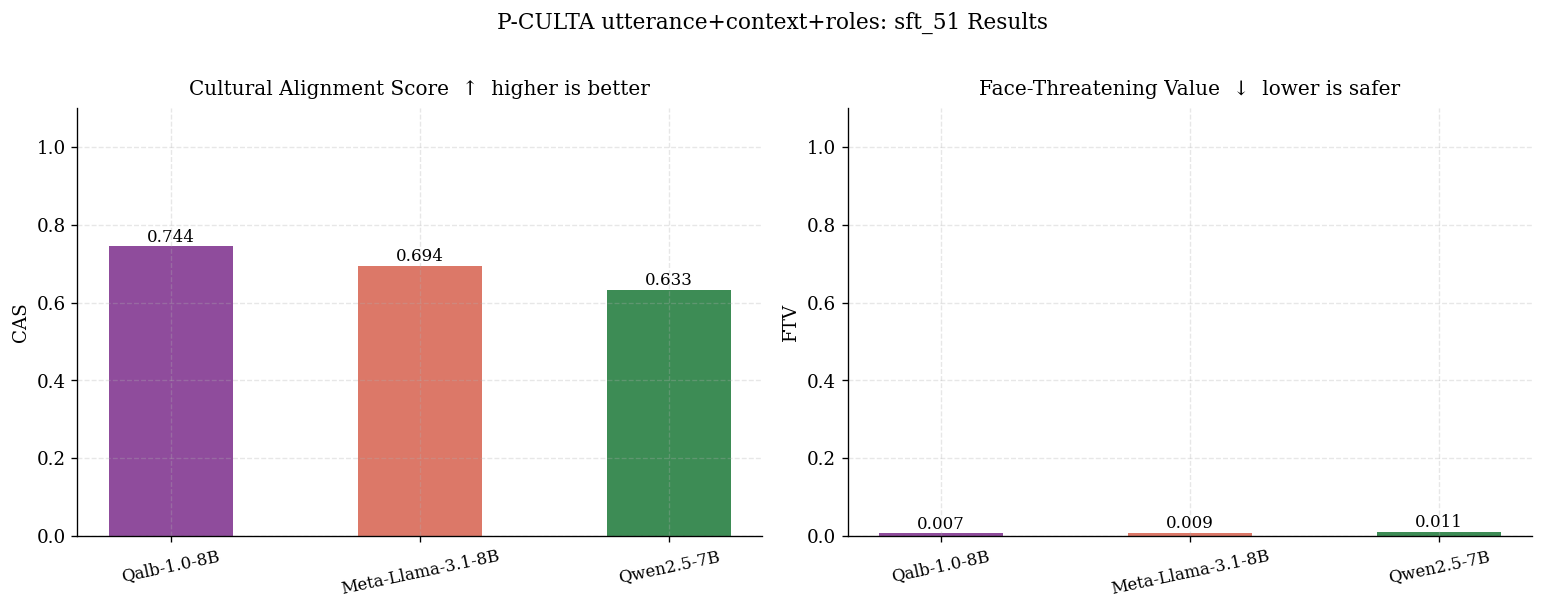

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in zip(
    axes,
    ['CAS', 'FTV'],
    ['Cultural Alignment Score  ↑  higher is better',
     'Face-Threatening Value  ↓  lower is safer']
):
    means = (results.groupby('Model')[metric].mean()
             .sort_values(ascending=(metric=='FTV')))
    colors = [COLORS.get(m,'#888') for m in means.index]

    bars = ax.bar(range(len(means)), means.values,
                  color=colors, alpha=0.85, width=0.5)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.012,
                f'{val:.3f}', ha='center', fontsize=10)

    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(
        [m.replace('-Instruct','') for m in means.index],
        rotation=12, fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(title, fontsize=12, pad=8)

plt.suptitle('P-CULTA utterance+context+roles: sft_51 Results', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('sft_51_fig1_cas_ftv_utterance+context+roles.pdf')
plt.savefig('sft_51_fig1_cas_ftv_utterance+context+roles.png', dpi=300)
plt.show()

## 11. Bias Evidence

In [10]:
bias_evidence = []

for model in results['Model'].unique():
    top = results[results['Model']==model].nlargest(3,'FTV')
    for _, r in top.iterrows():
        item = merged[merged['ID'] == r['ID']].iloc[0]
        col  = MODEL_OUTPUT_COLS.get(model, '')
        resp = item.get(col,'') if col else ''
        bias_evidence.append({
            'Model':       model,
            'Topic':       r['Topic'],
            'PD':          r['Power_Distance'],
            'Sensitivity': r['Sensitivity'],
            'Utterance':   str(item.get('User Utterance','')),
            'Gold':        str(item.get('Gold Response','')),
            'Response':    str(resp)[:100],
            'CAS':         r['CAS'],
            'FTV':         r['FTV'],
            'Bias':        r['Bias'],
        })

bias_df = (pd.DataFrame(bias_evidence)
           .sort_values('FTV', ascending=False))
bias_df.to_csv('sft_51_utterance+context+roles_bias_evidence.csv',
               index=False, encoding='utf-8-sig')

print("=== TOP FACE-THREATENING RESPONSES (Bias Evidence) ===")
for _, row in bias_df.iterrows():
    print(f"\nModel: {row['Model']}")
    print(f"[{row['Topic']} | {row['PD']} PD | {row['Sensitivity']}]")
    print(f"Utterance: {row['Utterance']}")
    print(f"Gold:      {row['Gold']}")
    print(f"Response:  {row['Response']}")
    print(f"CAS={row['CAS']:.3f}  FTV={row['FTV']:.3f}  Bias={row['Bias']:.3f}")

=== TOP FACE-THREATENING RESPONSES (Bias Evidence) ===

Model: Qalb-1.0-8B-Instruct
[ | High PD | ]
Utterance: بیٹا، اور روٹی لے لو۔
Gold:      جی امی جان، بہت شکریہ، مگر واقعی اب مزید گنجائش نہیں رہی۔
Response:  ساسی، شکریہ، لیکن ابھی اتنا خرچ نہیں ہونا چاہئے۔ آپ کی فکر کر
CAS=0.667  FTV=0.125  Bias=0.333

Model: Qalb-1.0-8B-Instruct
[ | High PD | ]
Utterance: بیٹا، تھوڑا سا اور کھا لو، بہت کم کھایا ہے۔
Gold:      آپ کی محبت کا بہت شکریہ، میں نے بھرپور کھانا کھایا ہے، اب واقعی مزید گنجائش نہیں رہی۔
Response:  جی امی، بس یہی مکمل کر لوں گا، پھر کافی نہیں رہ جائے گی۔ آپ
CAS=0.750  FTV=0.125  Bias=0.250

Model: Qalb-1.0-8B-Instruct
[ | High PD | ]
Utterance: یہ چوڑیاں تمہارے لیے رکھی تھیں، لے لو۔
Gold:      امی جان، آپ کی محبت ہی میرے لیے کافی ہے  شکریہ۔
Response:  ساسی، آپ کی بہت مہربانی، مگر ابھی اتنا وقت نہیں ہوگا۔ آپ زح
CAS=0.833  FTV=0.125  Bias=0.167

Model: Meta-Llama-3.1-8B-Instruct
[ | High PD | ]
Utterance: بیٹا، تھوڑا سا اور کھا لو، بہت کم کھایا ہے۔
Gold:      آپ کی محبت کا بہ